In [26]:
import importlib.util
import subprocess
import sys
from time import perf_counter


def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("lime")
ensure_package("scikit-image", "skimage")
ensure_package("shap")
ensure_package("xgboost")

In [27]:
# 예제 5.1 sklearn 패키지의 20 news groups 데이터 세트를 가져오는 코드

from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

# making class names shorter
class_names = [x.split('.')[-1] if 'misc' not in x else '.'.join(x.split('.')[-2:]) for x in newsgroups_train.target_names]

print(class_names)

class_names[3] = 'pc.hardware'
class_names[4] = 'mac.hardware'
print(class_names)


['atheism', 'graphics', 'ms-windows.misc', 'hardware', 'hardware', 'x', 'misc.forsale', 'autos', 'motorcycles', 'baseball', 'hockey', 'crypt', 'electronics', 'med', 'space', 'christian', 'guns', 'mideast', 'politics.misc', 'religion.misc']
['atheism', 'graphics', 'ms-windows.misc', 'pc.hardware', 'mac.hardware', 'x', 'misc.forsale', 'autos', 'motorcycles', 'baseball', 'hockey', 'crypt', 'electronics', 'med', 'space', 'christian', 'guns', 'mideast', 'politics.misc', 'religion.misc']


In [28]:
# 예제 5.2 제보 기사의 카테고리를 분류하는 모델을 만들고 F1-점수를 측정하는 코드

import sklearn
import sklearn.metrics
from sklearn.naive_bayes import MultinomialNB

# TF-IDF를 사용해서 문서를 숫자 벡터로 변환하는 전처리 과정
vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(lowercase=False)
train_vectors = vectorizer.fit_transform(newsgroups_train.data)
test_vectors = vectorizer.transform(newsgroups_test.data)

# learning
nb = MultinomialNB(alpha=.01)
nb.fit(train_vectors, newsgroups_train.target)

# testing
pred = nb.predict(test_vectors)
sklearn.metrics.f1_score(newsgroups_test.target, pred, average='weighted')


0.8350184193998175

In [29]:
# 예제 5.3 파이프라인 기술을 사용해 테스트 데이터 인덱스 0번에 데이터 벡터라이저와 카테고리 분류를 한꺼번에 수행하는 과정

from sklearn.pipeline import make_pipeline
pipe = make_pipeline(vectorizer, nb)
predict_classes = pipe.predict_proba([newsgroups_test.data[0]]).round(3)[0]

print(predict_classes)


[0.001 0.01  0.003 0.047 0.006 0.002 0.003 0.521 0.022 0.008 0.025 0.
 0.331 0.003 0.006 0.    0.003 0.    0.001 0.009]


In [30]:
# 예제 5.4 데이터 분류 결과의 가독성을 높이기 위해 출력을 수정하는 코드

rank = sorted(range(len(predict_classes)), key=lambda i: predict_classes[i], reverse=True)
for rank_index in rank:
    print('[{:>5}] \t{:<3}\tclass ({:.1%})'.format(rank.index(rank_index) + 1, rank_index, predict_classes[rank_index]))


[    1] 	7  	class (52.1%)
[    2] 	12 	class (33.1%)
[    3] 	3  	class (4.7%)
[    4] 	10 	class (2.5%)
[    5] 	8  	class (2.2%)
[    6] 	1  	class (1.0%)
[    7] 	19 	class (0.9%)
[    8] 	9  	class (0.8%)
[    9] 	4  	class (0.6%)
[   10] 	14 	class (0.6%)
[   11] 	2  	class (0.3%)
[   12] 	6  	class (0.3%)
[   13] 	13 	class (0.3%)
[   14] 	16 	class (0.3%)
[   15] 	5  	class (0.2%)
[   16] 	0  	class (0.1%)
[   17] 	18 	class (0.1%)
[   18] 	11 	class (0.0%)
[   19] 	15 	class (0.0%)
[   20] 	17 	class (0.0%)


In [31]:
# 예제 5.5 LIME 텍스트 설명체를 선언하는 코드

from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=class_names)

In [32]:
# 예제 5.6 LIME의 explain_instance 메서드에 필요한 최소한의 파라미터를 넣었다

exp = explainer.explain_instance(newsgroups_test.data[0], pipe.predict_proba, top_labels=1)

In [33]:
# 예제 5.7 LIME이 잘 작동하는지 확인하기 위한 메서드

exp.available_labels()

[np.int64(7)]

In [34]:
# 예제 5.8 explainer가 0번 테스트 데이터를 해석한 결과를 iPython 노트북으로 출력하는 코드

exp.show_in_notebook(text=newsgroups_test.data[0])

In [35]:
# 예제 5.9 테스트 데이터 5번을 LIME 알고리즘에 입력하는 코드

from lime.lime_text import LimeTextExplainer

idx = 5

explainer = LimeTextExplainer(class_names=class_names)
exp = explainer.explain_instance(newsgroups_test.data[idx], pipe.predict_proba, top_labels=1)
predict_classes = pipe.predict_proba([newsgroups_test.data[idx]]).round(3)[0]
rank = sorted(range(len(predict_classes)), key=lambda i: predict_classes[i], reverse=True)

print('Document id: %d' % idx)
print('Predicted class: %s' % class_names[nb.predict(test_vectors[idx]).reshape(1,-1)[0,0]])
print('True class: %s' % class_names[newsgroups_test.target[idx]])
print(predict_classes)

print(rank)
print ('Explanation for class %s' % class_names[rank[0]])
print ('\n'.join(map(str, exp.as_list(rank[0]))))

exp.show_in_notebook(text=newsgroups_test.data[idx])

Document id: 5
Predicted class: med
True class: med
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[13, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]
Explanation for class med
(np.str_('infection'), 0.0018056619099248866)
(np.str_('yeast'), 0.0017980747170551394)
(np.str_('Candida'), 0.001679928118453688)
(np.str_('infections'), 0.0016127130592141457)
(np.str_('fungus'), 0.0015150602272327941)
(np.str_('ocom'), 0.001476728489776554)
(np.str_('blooms'), 0.0014323976017517482)
(np.str_('patients'), 0.0014080815196439707)
(np.str_('systemic'), 0.0013563176355178683)
(np.str_('Microbiology'), 0.001327283356557572)


(np.float64(-0.5), np.float64(1279.5), np.float64(1279.5), np.float64(-0.5))

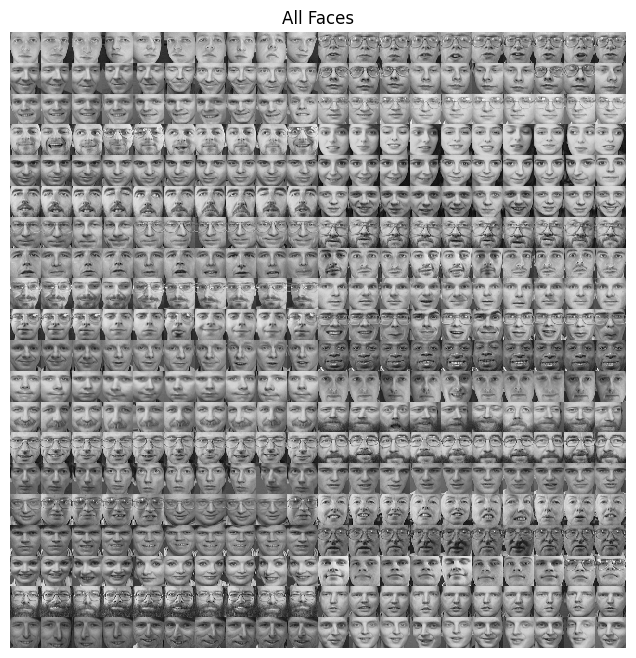

In [36]:
# 예제 5.10 scikit-image 패키지를 사용해서 올리베티 얼굴 데이터를 로드하고 확인하는 코드

import numpy as np
import matplotlib.pyplot as plt
from skimage.color import gray2rgb, rgb2gray

from skimage.util import montage

from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()

# make each image color so lime_image works correctly

X_vec = np.stack([gray2rgb(iimg) for iimg in faces.data.reshape((-1, 64, 64))],0)
y_vec = faces.target.astype(np.uint8)

%matplotlib inline

fig, ax1 = plt.subplots(1,1, figsize = (8,8))
ax1.imshow(montage(X_vec[:,:,:,0]), cmap='gray', interpolation = 'none')
ax1.set_title('All Faces')
ax1.axis('off')


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

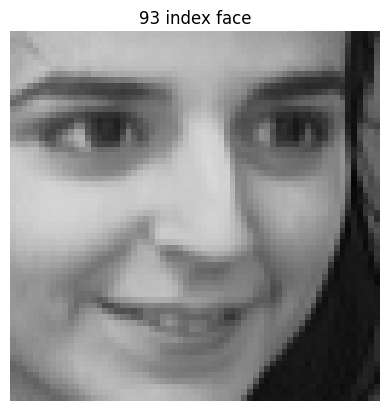

In [37]:
# 예제 5.11 이미지 데이터 한 장을 그리는 코드

index = 93
plt.imshow(X_vec[index], cmap='gray')
plt.title('{} index face'.format(index))
plt.axis('off')

In [38]:
# 예제 5.12 텐서플로를 이용한 분류 모델을 LIME에서 사용할 수 있게 컨벤션을 맞추는 코드

def predict_proba(image):
    return session.run(model_predict, feed_dict={preprocessed_image: image})

In [39]:
# 예제 5.13 sklearn 패키지에 있는 train_test_split 함수를 사용해서 X_vec과 y_vec으로부터 학습용과 테스트용 데이터세트를 분리하는 코드

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_vec, y_vec, train_size=0.70)

In [40]:
# 예제 5.14 MLP가 학습할 수 있도록 이미지 전처리를 수행하는 파이프라인 생성

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
class PipeStep(object):
    """ Wrapper for turning functions into pipeline transforms (no-fitting) """
    def __init__(self, step_func):
        self._step_func=step_func
    def fit(self,*args):
        return self
    def transform(self,X):
        return self._step_func(X)

makegray_step = PipeStep(lambda img_list: [rgb2gray(img) for img in img_list])
flatten_step = PipeStep(lambda img_list: [img.ravel() for img in img_list])
simple_pipeline = Pipeline([
    ('Make Gray', makegray_step),
    ('Flatten Image', flatten_step),
    ('MLP', MLPClassifier(
        activation='relu',
        hidden_layer_sizes=(400, 40),
    random_state=1))
])


In [41]:
# 예제 5.15 학습 데이터를 MLP가 있는 파이프라인에 붓는 코드


simple_pipeline.fit(X_train, y_train)

/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,steps,"[('Make Gray', ...), ('Flatten Image', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,hidden_layer_sizes,"(400, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001


In [42]:
# 예제 5.16 classification_report를 사용해서 모델 성능을 테스트하는 코드

def test_model(X_test, y_test):
  pipe_pred_test = simple_pipeline.predict(X_test)
  pipe_pred_prop = simple_pipeline.predict_proba(X_test)

  from sklearn.metrics import classification_report
  print(classification_report(y_true=y_test, y_pred = pipe_pred_test))

test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       1.00      0.60      0.75         5
           2       1.00      1.00      1.00         2
           3       0.20      0.50      0.29         2
           4       1.00      1.00      1.00         3
           5       0.67      0.40      0.50         5
           6       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         6
           8       0.43      0.75      0.55         4
           9       0.50      1.00      0.67         1
          10       1.00      1.00      1.00         2
          11       1.00      0.75      0.86         4
          12       0.25      0.33      0.29         3
          13       1.00      0.80      0.89         5
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         6
          16       1.00      0.50      0.67         2
          17       0.50    

/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [43]:
# 예제 5.17 Normalizer 전처리 과정을 추가해서 MLP를 학습시키는 코드

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.neural_network import MLPClassifier
class PipeStep(object):
    """ Wrapper for turning functions into pipeline transforms (no-fitting) """
    def __init__(self, step_func):
        self._step_func=step_func
    def fit(self,*args):
        return self
    def transform(self,X):
        return self._step_func(X)


makegray_step = PipeStep(lambda img_list: [rgb2gray(img) for img in img_list])
flatten_step = PipeStep(lambda img_list: [img.ravel() for img in img_list])

simple_pipeline = Pipeline([
    ('Make Gray', makegray_step),
    ('Flatten Image', flatten_step),
    ('Normalize', Normalizer()),
    # add Normalizer preprocessing step
    ('MLP', MLPClassifier(
        activation='relu',
        hidden_layer_sizes=(400, 40),
        random_state=1)),
])

simple_pipeline.fit(X_train, y_train)

test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       1.00      0.60      0.75         5
           2       0.40      1.00      0.57         2
           3       0.33      0.50      0.40         2
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         6
           8       0.80      1.00      0.89         4
           9       0.50      1.00      0.67         1
          10       0.67      1.00      0.80         2
          11       1.00      0.75      0.86         4
          12       0.50      0.67      0.57         3
          13       1.00      0.80      0.89         5
          14       1.00      1.00      1.00         2
          15       0.00      0.00      0.00         6
          16       1.00      1.00      1.00         2
          17       1.00    

/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklea

In [44]:
# 예제 5.18 필자가 찾은 최적의 파이프라인 조합

simple_pipeline = Pipeline([
    ('Make Gray', makegray_step),
    ('Flatten Image', flatten_step),
    ('Normalize', Normalizer()),
    # add Normalizer preprocessing step
    ('MLP', MLPClassifier(
        activation='relu',
        alpha=1e-7,
        epsilon=1e-6,
        hidden_layer_sizes=(800, 120),
        random_state=1)),
])

simple_pipeline.fit(X_train, y_train)

test_model(X_test, y_test)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       1.00      1.00      1.00         5
           2       0.40      1.00      0.57         2
           3       0.20      0.50      0.29         2
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         3
           7       0.50      0.17      0.25         6
           8       1.00      1.00      1.00         4
           9       0.25      1.00      0.40         1
          10       0.50      1.00      0.67         2
          11       1.00      1.00      1.00         4
          12       0.50      0.67      0.57         3
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00         2
          15       0.80      0.67      0.73         6
          16       1.00      1.00      1.00         2
          17       0.80    

/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/songhune/.pyenv/versions/llm/lib/python3.10/site-packages/sklea

In [45]:
# 예제 5.19 LIME의 이미지 설명체와 이미지 분할 알고리즘을 선언하는 코드

from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

explainer = lime_image.LimeImageExplainer()

# segmenter algorithms: quickshift(default), slic, felzenszwalb
segmenter = SegmentationAlgorithm(
        'slic',
        n_segments=100,
        compactness=1,
        sigma=1)


In [46]:
# 예제 5.20 테스트 0번 이미지에 대해 설명 모델을 구축하는 코드

olivetti_test_index = 0
start_time = perf_counter()

exp = explainer.explain_instance(
    X_test[olivetti_test_index],
    classifier_fn=simple_pipeline.predict_proba,
    top_labels=6,
    num_samples=1000,
    segmentation_fn=segmenter)

elapsed_time = perf_counter() - start_time
print(f"explain_instance elapsed time: {elapsed_time:.3f} seconds")

  0%|          | 0/1000 [00:00<?, ?it/s]

explain_instance elapsed time: 0.295 seconds


Text(0.5, 1.0, 'Show mask only')

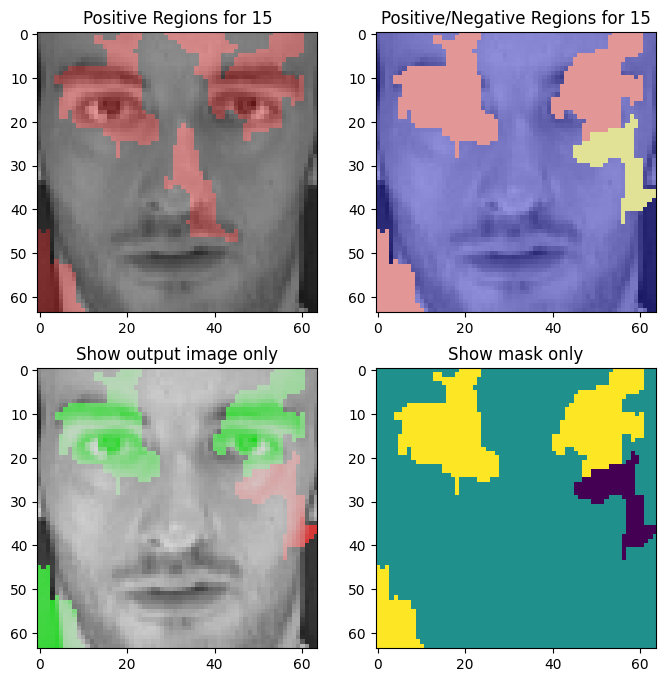

In [47]:
# 예제 5.21 올리베티 데이터 0번을 설명체에 통과시켜 XAI를 수행하는 코드

from skimage.color import label2rgb
# set canvas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (8, 8))

# show positive segments
temp, mask = exp.get_image_and_mask(
    y_test[olivetti_test_index],
    positive_only=True,
    num_features=8,
    hide_rest=False)

ax1.imshow(
        label2rgb(mask, temp, bg_label = 0),
        interpolation = 'nearest')

ax1.set_title('Positive Regions for {}'.format(y_test[olivetti_test_index]))

# show all segments
temp, mask = exp.get_image_and_mask(
    y_test[olivetti_test_index],
    positive_only=False,
    num_features=8,
    hide_rest=False)

ax2.imshow(
    label2rgb(4 - mask, temp, bg_label = 0),
    interpolation = 'nearest')

ax2.set_title('Positive/Negative Regions for {}'.format(y_test[olivetti_test_index]))

# show image only
ax3.imshow(temp, interpolation = 'nearest')
ax3.set_title('Show output image only')

# show mask only
ax4.imshow(mask, interpolation = 'nearest')
ax4.set_title('Show mask only')

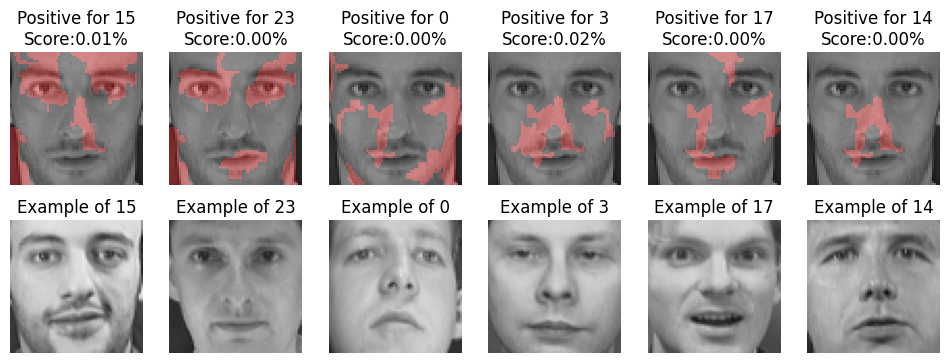

In [48]:
# 예제 5.22 올리베티 얼굴 테스트 데이터 0번(3번 인물)으로부터 추가 설명을 출력하는 코드

def show_extra_info(test, test_index):

    pipe_pred_test = simple_pipeline.predict(test)
    pipe_pred_prop = simple_pipeline.predict_proba(test)
    # now show them for each class
    fig, m_axs = plt.subplots(2,6, figsize = (12,4))
    for i, (c_ax, gt_ax) in zip(exp.top_labels, m_axs.T):
        temp, mask = exp.get_image_and_mask(
                i,
                positive_only=True,
                num_features=12,
                hide_rest=False,
                min_weight=0.001)

        c_ax.imshow(
                label2rgb(mask,temp, bg_label = 0),
                interpolation = 'nearest')
        c_ax.set_title('Positive for {}\nScore:{:2.2f}%'.format(i, 100*pipe_pred_prop[test_index, i]))

        c_ax.axis('off')

        face_id = np.random.choice(np.where(y_train==i)[0])

        gt_ax.imshow(X_train[face_id])
        gt_ax.set_title('Example of {}'.format(i))
        gt_ax.axis('off')

show_extra_info(X_test, 1)

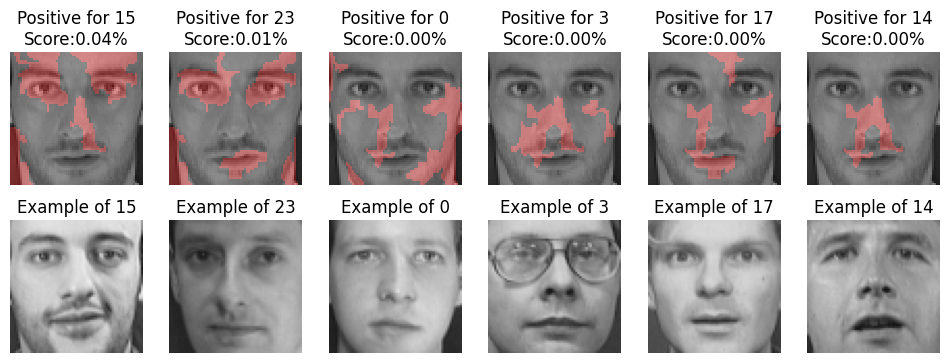

In [49]:
# 그림 5.36용

show_extra_info(X_test, 25)

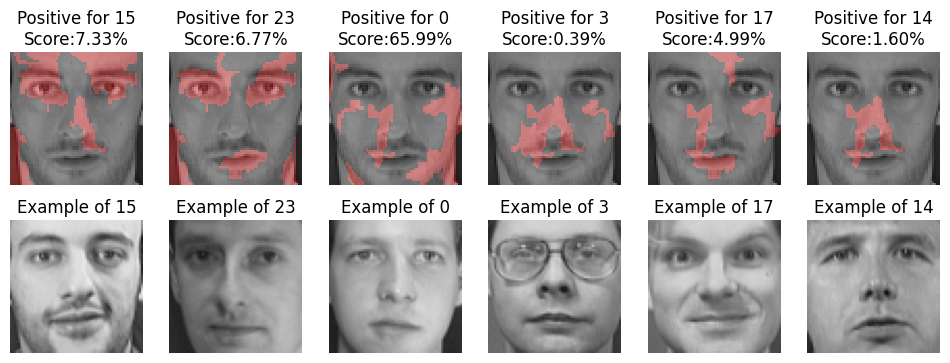

In [50]:
# 그림 5.37용

show_extra_info(X_test, 101)

In [57]:
# 예제 5.23 SHAP 모듈로부터 보스턴 데이터세트를 불러와서 학습용과 테스트용 데이터세트로 분리하는 코드

import shap
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

if hasattr(shap.datasets, "boston"):
    X, y = shap.datasets.boston()
else:
    boston = fetch_openml(name="boston", version=1, as_frame=True)
    X = boston.data
    y = boston.target.astype(float)

if hasattr(X, "select_dtypes"):
    category_columns = X.select_dtypes(include=["category"]).columns
    if len(category_columns) > 0:
        X = X.copy()
        for column in category_columns:
            X[column] = X[column].cat.codes.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train[:10]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
42,0.14150,0.0,6.91,0,0.448,6.169,6.6,5.7209,3,233.0,17.9,383.37,5.81
58,0.15445,25.0,5.13,0,0.453,6.145,29.2,7.8148,8,284.0,19.7,390.68,6.86
385,16.81180,0.0,18.10,0,0.700,5.277,98.1,1.4261,2,666.0,20.2,396.90,30.81
78,0.05646,0.0,12.83,0,0.437,6.232,53.7,5.0141,5,398.0,18.7,386.40,12.34
424,8.79212,0.0,18.10,0,0.584,5.565,70.6,2.0635,2,666.0,20.2,3.65,17.16
160,1.27346,0.0,19.58,1,0.605,6.250,92.6,1.7984,5,403.0,14.7,338.92,5.50
185,0.06047,0.0,2.46,0,0.488,6.153,68.8,3.2797,3,193.0,17.8,387.11,13.15
101,0.11432,0.0,8.56,0,0.520,6.781,71.3,2.8561,5,384.0,20.9,395.58,7.67
268,0.54050,20.0,3.97,0,0.575,7.470,52.6,2.8720,5,264.0,13.0,390.30,3.16
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296.0,16.6,395.50,9.04


Text(0, 0.5, 'MEDV \n Price $1,000')

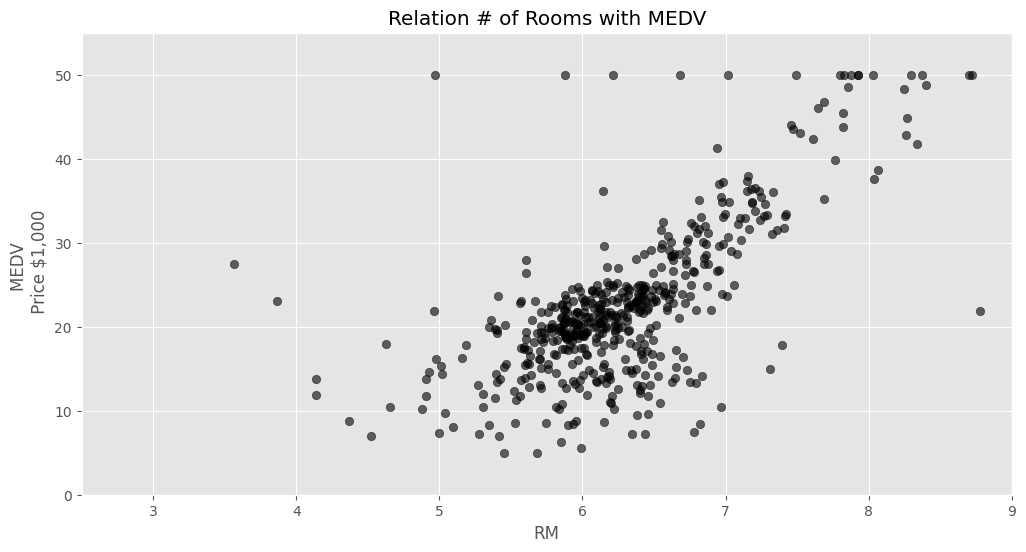

In [52]:
# 예제 5.23 방의 개수와 집값 간의 관계를 산점도로 그리는 코드

# drawing scatter plot
import matplotlib.pylab as plt
import matplotlib

%matplotlib inline

matplotlib.style.use('ggplot')

fig, ax1 = plt.subplots(1,1, figsize = (12,6))

ax1.scatter(X['RM'], y, color='black', alpha=0.6)
ax1.set_title('Relation # of Rooms with MEDV')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV \n Price $1,000')


In [53]:
# 예제 5.38 선형 모델을 이용해서 방 개수와 주택 가격 간의 관계를 구하는 코드

from sklearn import linear_model
import pandas as pd

linear_regression = linear_model.LinearRegression()
linear_regression.fit(X=pd.DataFrame(X_train['RM']), y=y_train)
prediction = linear_regression.predict(X=pd.DataFrame(X_test['RM']))

print('a value: ', linear_regression.intercept_)
print('b value: ', linear_regression.coef_)
print('MEDV = {:.2f} * RM {:.2f}'.format(linear_regression.coef_[0], linear_regression.intercept_))


a value:  -32.39552264560754
b value:  [8.76050748]
MEDV = 8.76 * RM -32.40


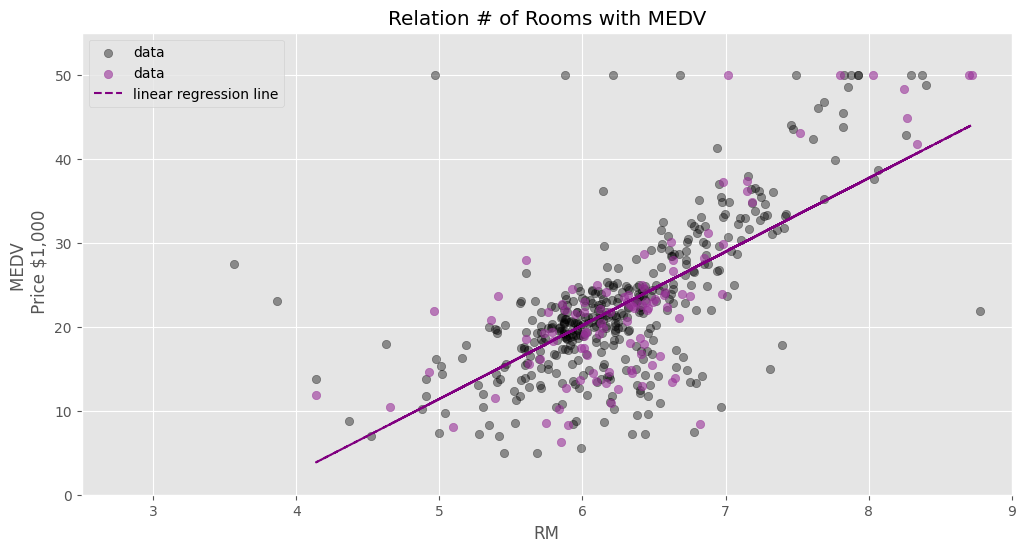

In [54]:
# 예제 5.39 방의 개수가 달라질 때 주택 매매 가격을 예측하는 그래프와 데이터를 한꺼번에 플롯으로 그리는 코드

# scatter Train, Test data with Linear Regression Prediction
fig, ax1 = plt.subplots(1,1, figsize = (12,6))
ax1.scatter(X_train['RM'], y_train, color='black', alpha=0.4, label='data')
ax1.scatter(X_test['RM'], y_test, color='#993299', alpha=0.6, label='data')
ax1.set_title('Relation # of Rooms with MEDV')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV \n Price $1,000')
ax1.plot(X_test['RM'], prediction, color='purple', alpha=1, linestyle='--', label='linear regression line')
ax1.legend()


In [55]:
# 예제 5.40 모델 예측치와 실제 집값 간의 RMSE를 구하는 코드

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, prediction))
print("RMSE: %f" % (rmse))


RMSE: 6.383135


In [58]:
# 예제 5.41 xgboost의 선형 회귀 모델로 주택 매매 가격을 예측하는 모델을 만들고 학습하는 코드

import xgboost

# train XGBoost model
model = xgboost.XGBRegressor(objective="reg:squarederror", random_state=1)
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [59]:
# 예제 5.42 전체 피처를 사용해서 학습시킨 모델의 RMSE를 구하는 코드

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE: %f" % (rmse))


RMSE: 3.193260


In [62]:
# 예제 5.43 SHAP의 설명체를 정의하고 섀플리 값을 계산하는 로직

# load JS visualization code to notebook
shap.initjs()

try:
    explainer = shap.TreeExplainer(model.get_booster())
    shap_values = explainer.shap_values(X_train)
    base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
except Exception:
    explainer = shap.Explainer(model.predict, X_train)
    shap_explanation = explainer(X_train)
    shap_values = shap_explanation.values
    base_value = float(np.asarray(shap_explanation.base_values).reshape(-1)[0])

# visualize the first prediction's explanation
# (use matplotlib=True to avoid Javascript)
shap.force_plot(base_value, shap_values[0, :], X_train.iloc[0, :])


PermutationExplainer explainer: 405it [00:14, 11.14it/s]                         


Text(0, 0.5, 'MEDV \n Price $1,000')

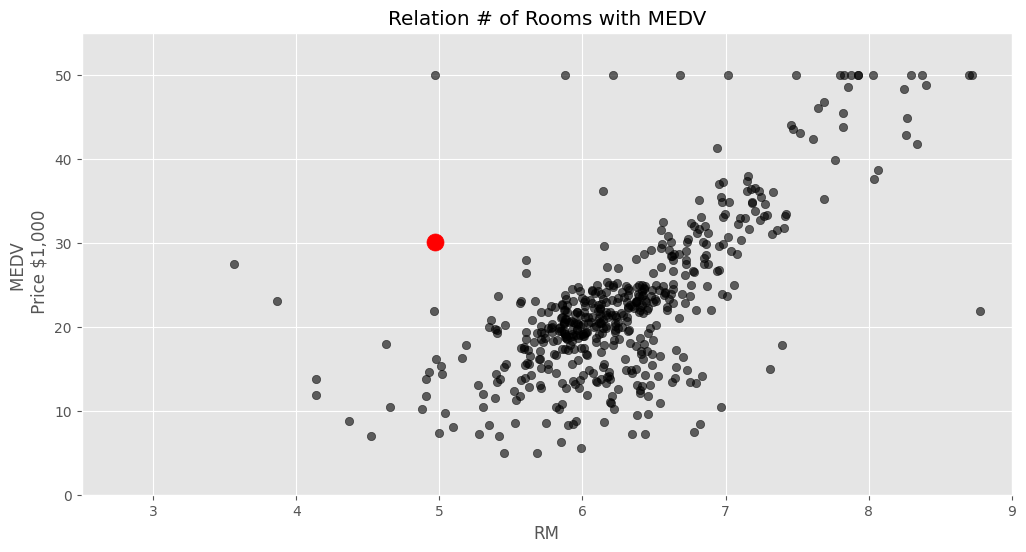

In [65]:
# 예제 5.44 259번 데이터에 대해서 방의 개수(RM)와 집 가격(MEDV)이 어떤 관계가 있는지 플롯으로 그리는 코드

fig, ax1 = plt.subplots(1,1, figsize = (12,6))

idx = 259
ax1.scatter(X['RM'], y, color='black', alpha=0.6)
ax1.scatter(X_train['RM'].iloc[idx], y_train[idx], c='red', s=150)
ax1.set_title('Relation # of Rooms with MEDV')
ax1.set_xlim(2.5, 9)
ax1.set_xlabel('RM')
ax1.set_ylim(0, 55)
ax1.set_ylabel('MEDV \n Price $1,000')


In [66]:
# 예제 5.45 데이터 259번에 대한 섀플리 영향도를 그리는 코드

# load JS visualization code to notebook
shap.initjs()

shap.force_plot(base_value, shap_values[259, :], X_train.iloc[259, :])


In [67]:
# 예제 5.46 전체 데이터에 대한 섀플리 값을 플롯으로 그리는 코드

# load JS visualization code to notebook
shap.initjs()

# visualize the training set predictions
shap.force_plot(base_value, shap_values, X_train)


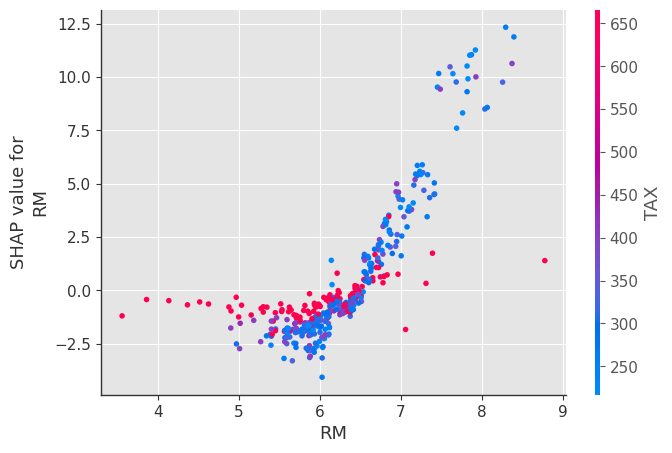

In [68]:
# 예제 5.47 방 개수 피처가 집값에 미치는 섀플리 영향도를 시각화하는 플롯

# create a SHAP dependence plot to show the effect
# of a single feature across the whole dataset
shap.dependence_plot("RM", shap_values, X_train)


/var/folders/jj/cj4b9h512gs7by1fyqkz5j5c0000gn/T/ipykernel_32912/2504435906.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)


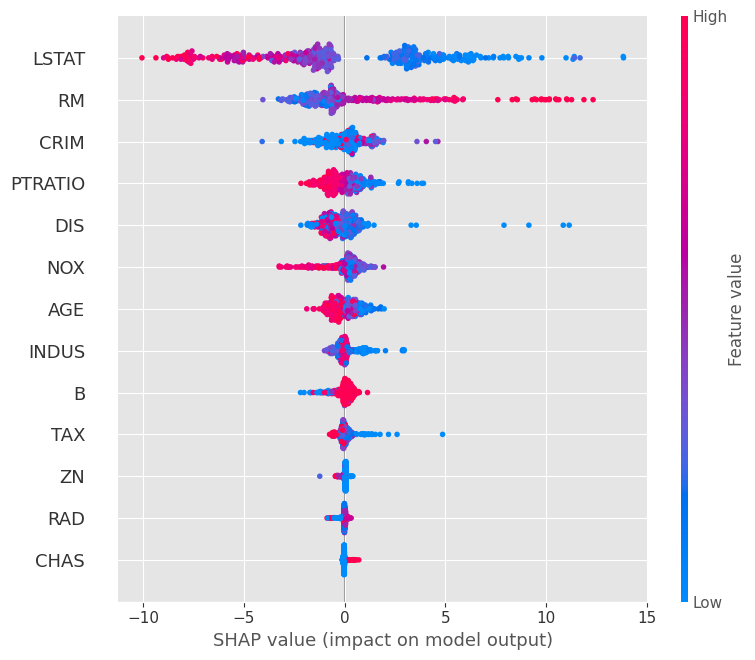

In [69]:
# 예제 5.48 전체 피처들이 섀플리 값 결정에 어떻게 관여하는지 시각화하는 코드

# summarize the effects of all the features

shap.summary_plot(shap_values, X_train)

/var/folders/jj/cj4b9h512gs7by1fyqkz5j5c0000gn/T/ipykernel_32912/1006393660.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar")


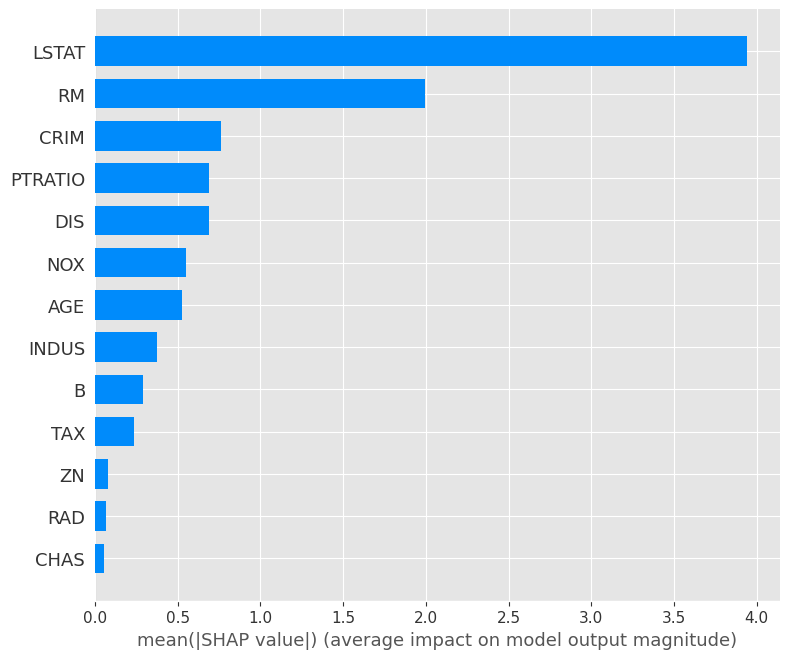

In [70]:
# 예제 5.49 피처별 섀플리 값을 막대 타입으로 비교하는 코드

shap.summary_plot(shap_values, X_train, plot_type="bar")

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

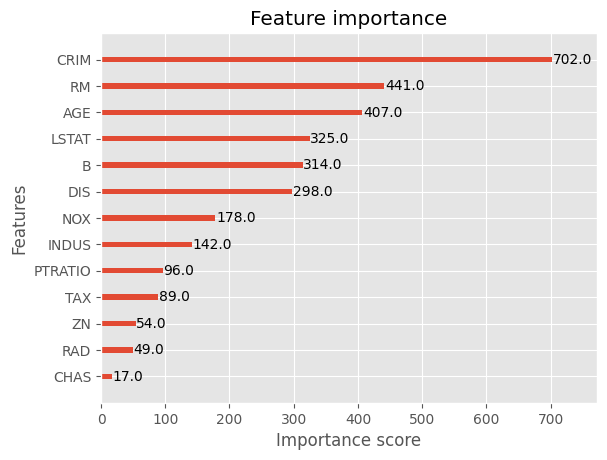

In [71]:
# 예제 5.50 xgboost의 피처 중요도를 호출하는 코드

xgboost.plot_importance(model)